# Project Overview

**Objective**

* Predict `PitNextLap` (binary classification) using high-fidelity F1 race telemetry and engineered features.
* Analyze the impact of tyre life and compound types on strategic pit window timing.
* Optimize pit stop detection by filtering race-anomalies (Safety Cars/Accidents) and accounting for class imbalance using SMOTE.

In [1]:
# Basic Libs
import numpy as np 
import pandas as pd 

# Visual Libs
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libs
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.metrics import ConfusionMatrixDisplay

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (18, 12)

# Data Acquisition

In [2]:
df = pd.read_csv("/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v3.csv")

# Initial Data Profiling & Structural Analysis

In [3]:
df.shape

(79511, 16)

In [4]:
df.describe()

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,79511.000000,79511.000000,79511.000000,79511.000000,79511.000000,79511.000000,79511.000000,79511.000000,79511.000000,79511.000000,79511.000000,79511.000000,79511.000000
mean,30.755531,2.038699,14.840437,9.797412,91.896198,2024.026738,-0.271768,-29.321900,0.235112,0.237011,0.439047,0.399587,0.002377
std,18.214034,0.948782,10.539932,5.424086,36.568538,0.807906,49.968165,74.806135,0.424072,0.425252,0.260152,0.266094,3.751109
min,1.000000,1.000000,1.000000,1.000000,67.012000,2023.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,15.000000,1.000000,7.000000,5.000000,81.623000,2023.000000,-6.023500,-48.465000,0.000000,0.000000,0.217949,0.177778,-1.000000
50%,30.000000,2.000000,13.000000,10.000000,90.542000,2024.000000,-0.025000,-20.874000,0.000000,0.000000,0.428571,0.350649,0.000000
75%,45.000000,3.000000,21.000000,14.000000,98.747000,2025.000000,3.556500,-4.275500,0.000000,0.000000,0.641026,0.588235,1.000000
max,78.000000,8.000000,78.000000,20.000000,2526.253000,2025.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000


In [5]:
df.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [6]:
df.isnull().sum()

Driver                    0
LapNumber                 0
Compound                  0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
Race                      0
Year                      0
LapTime_Delta             0
Cumulative_Degradation    0
PitStop                   0
PitNextLap                0
RaceProgress              0
Normalized_TyreLife       0
Position_Change           0
dtype: int64

In [7]:
dff = df.duplicated().sum()
print(dff)

0


In [8]:
print("Compounds present:", df['Compound'].unique())
print("Number of unique Races:", df['Race'].nunique())
print("Number of unique Drivers:", df['Driver'].nunique())

Compounds present: ['MEDIUM' 'HARD' 'SOFT' 'INTERMEDIATE' 'WET']
Number of unique Races: 25
Number of unique Drivers: 28


In [9]:
print("Target Variable (PitNextLap) Distribution:")
print(df['PitNextLap'].value_counts(normalize=True) * 100)

Target Variable (PitNextLap) Distribution:
PitNextLap
0    76.298877
1    23.701123
Name: proportion, dtype: float64


In [10]:
print("Skewness of LapTime (s):", df['LapTime (s)'].skew())

Skewness of LapTime (s): 56.87203051999305


# Data Cleaning 

## Telemetry Filtering

In [11]:
df_cleaned = df.copy()
median_lap = df_cleaned['LapTime (s)'].median()
outlier_threshold = median_lap * 1.5
df_cleaned = df_cleaned[df_cleaned['LapTime (s)'] < outlier_threshold]
print(f"Removed {len(df) - len(df_cleaned)} outlier laps (Safety Cars/Accidents).")

Removed 937 outlier laps (Safety Cars/Accidents).


## Noise Reduction

In [12]:
cols_to_drop = ['PitStop', 'Normalized_TyreLife', 'Year'] 
df_cleaned = df_cleaned.drop(columns=cols_to_drop)

print(f"Remaining columns for analysis: {df_cleaned.columns.tolist()}")

Remaining columns for analysis: ['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Race', 'LapTime_Delta', 'Cumulative_Degradation', 'PitNextLap', 'RaceProgress', 'Position_Change']


**Observation**

The dataset contains 16 initial features. Data cleaning focused on removing 937 telemetry outliers and dropping redundant normalized features to prevent Multicollinearity, ensuring the model prioritizes physical degradation over mathematical scaling.

# Exploratory Data Analysis (EDA)

## Univariate Analysis: Feature Distributions

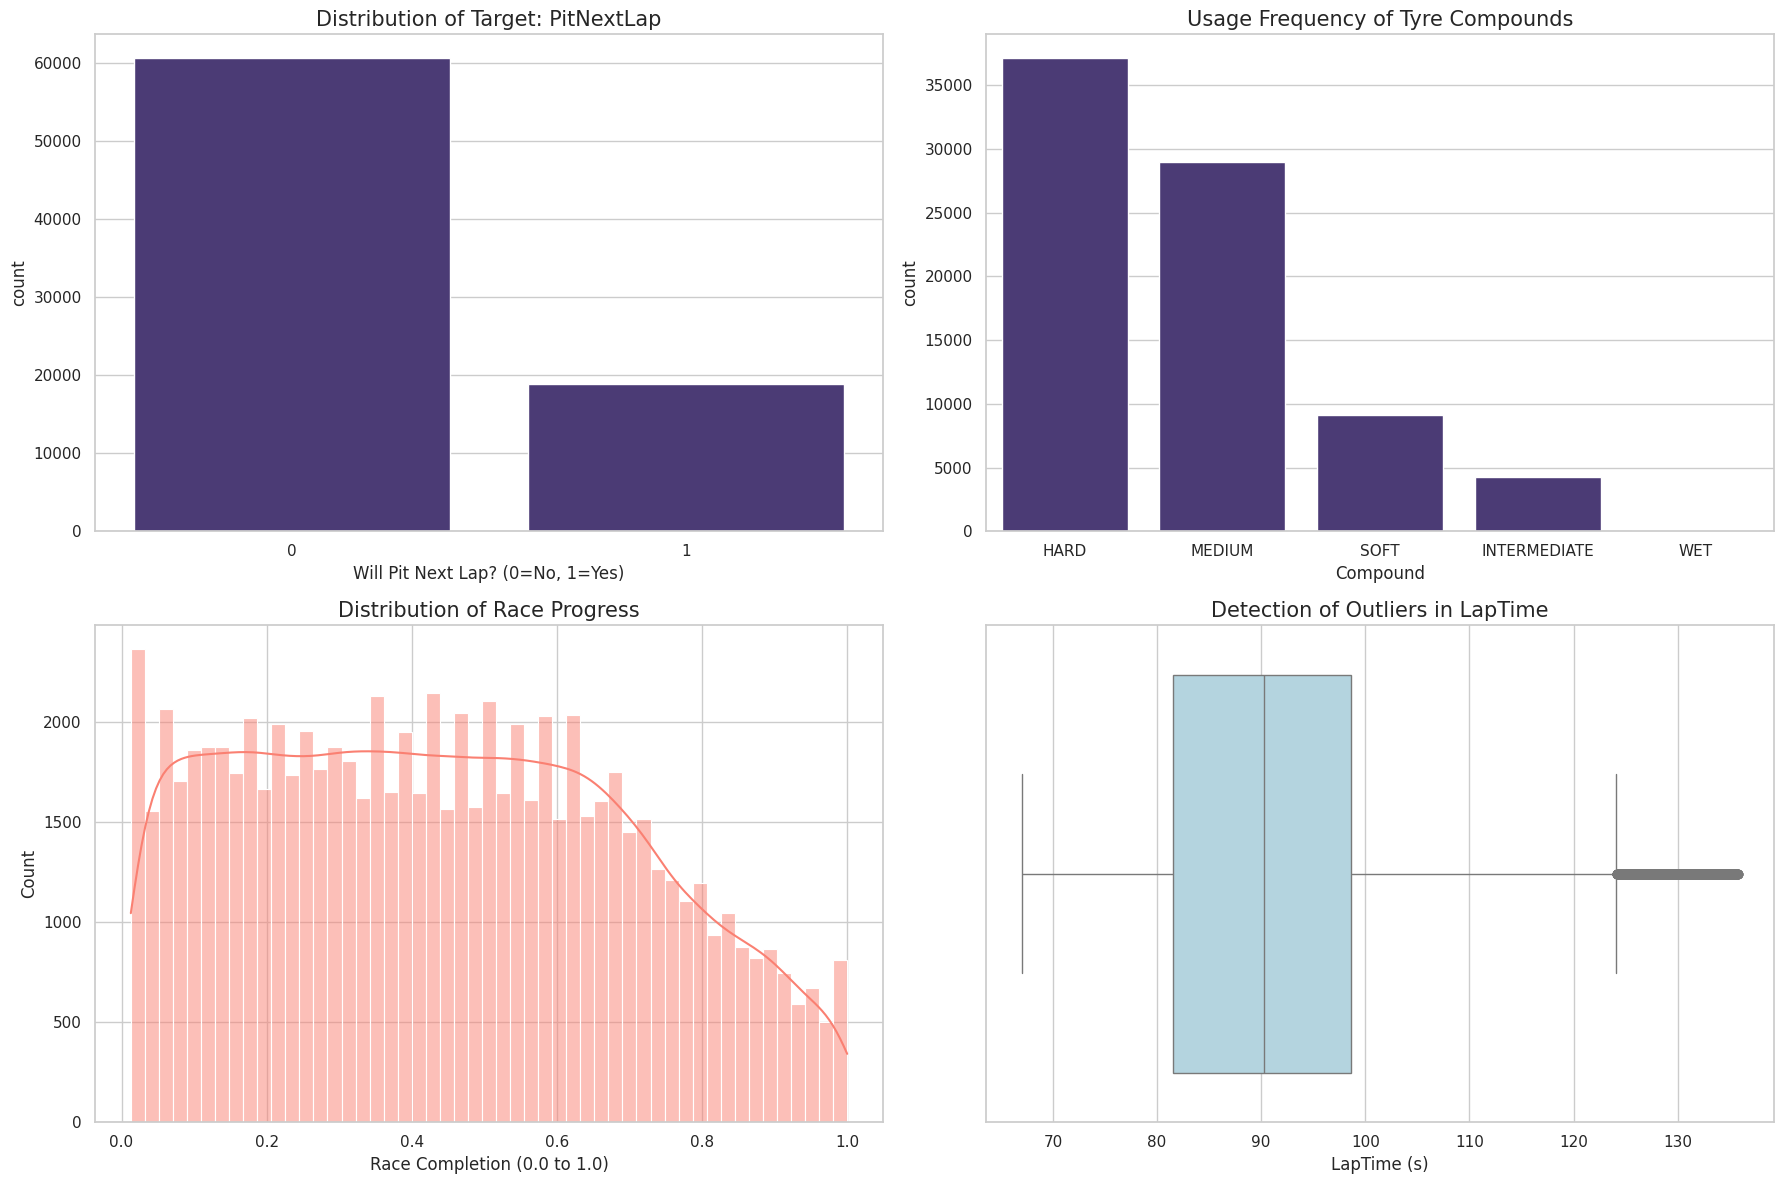

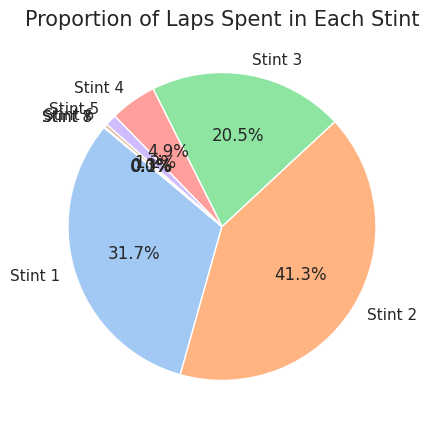

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Target Variable Distribution (PitNextLap)
sns.countplot(data=df, x='PitNextLap', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Target: PitNextLap', fontsize=15)
axes[0, 0].set_xlabel('Will Pit Next Lap? (0=No, 1=Yes)')

# Tyre Compound Usage
sns.countplot(data=df, x='Compound', order=df['Compound'].value_counts().index, ax=axes[0, 1])
axes[0, 1].set_title('Usage Frequency of Tyre Compounds', fontsize=15)

# Race Progress Distribution
sns.histplot(df['RaceProgress'], kde=True, color='salmon', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Race Progress', fontsize=15)
axes[1, 0].set_xlabel('Race Completion (0.0 to 1.0)')

# Outlier Detection: LapTime (s)
sns.boxplot(x=df_cleaned['LapTime (s)'], ax=axes[1, 1], color='lightblue')
axes[1, 1].set_title('Detection of Outliers in LapTime', fontsize=15)

plt.tight_layout()
plt.show()

# Stint Count - Unique Visual
plt.figure(figsize=(10, 5))
stint_counts = df.groupby('Stint')['LapNumber'].count()
plt.pie(stint_counts, labels=[f'Stint {i}' for i in stint_counts.index], 
        autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of Laps Spent in Each Stint', fontsize=15)
plt.show()

**Observation**

* **Class Imbalance**: The target variable PitNextLap shows a significant 4:1 imbalance, necessitating a recall-focused evaluation approach.
* **Compound Strategy**: Hard and Medium compounds dominate race stints, while Wet/Intermediate usage is statistically negligible.
* **Stint Dynamics**: Most races follow a 1-stop or 2-stop pattern, with over 70% of the data concentrated in the first two stints.

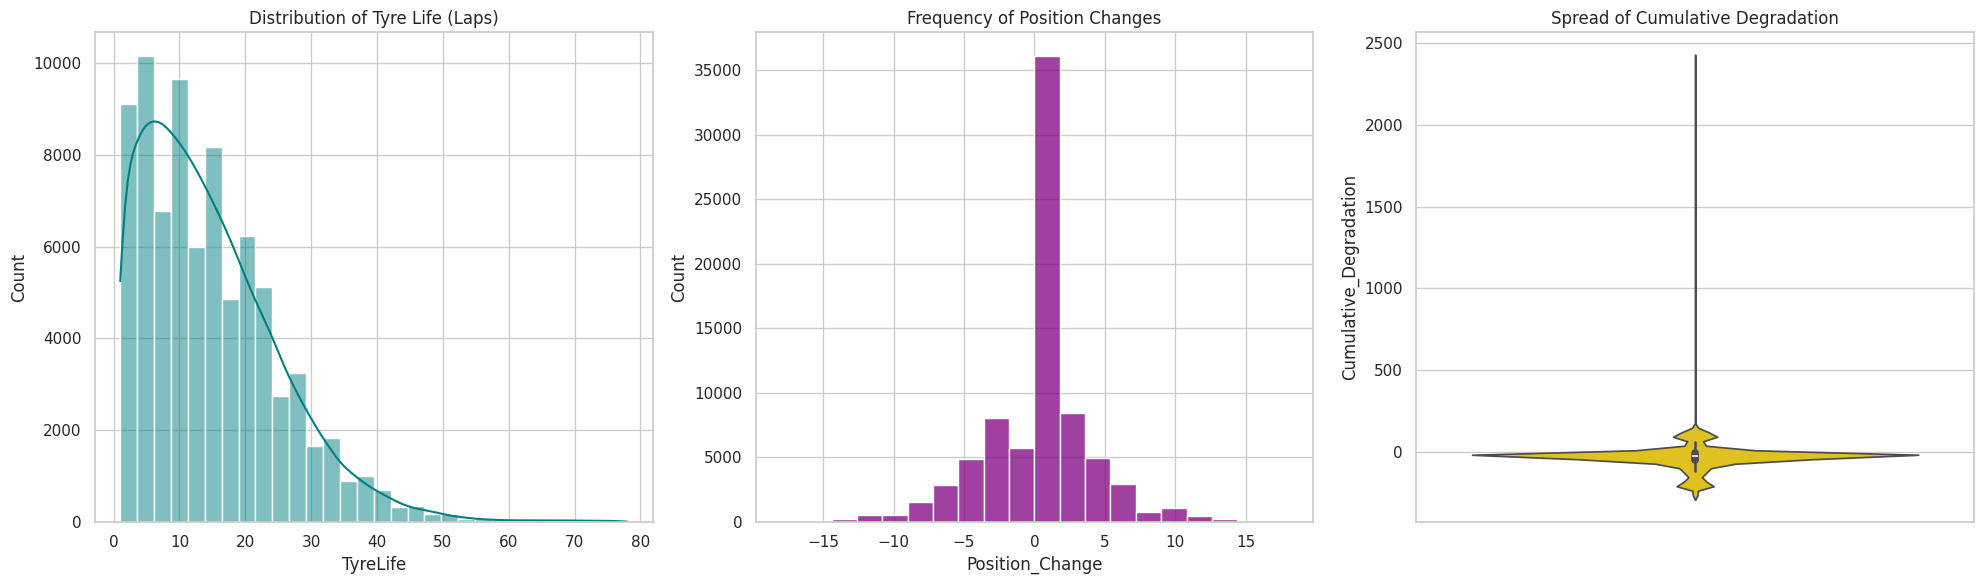

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Tyre Life Distribution
sns.histplot(df['TyreLife'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Tyre Life (Laps)')

# Position Change Distribution
sns.histplot(df['Position_Change'], bins=20, kde=False, ax=axes[1], color='purple')
axes[1].set_title('Frequency of Position Changes')

# Cumulative Degradation
sns.violinplot(y=df['Cumulative_Degradation'], ax=axes[2], color='gold')
axes[2].set_title('Spread of Cumulative Degradation')

plt.tight_layout()
plt.show()

**Observation**

 **Tyre Ceiling**: Physical tyre longevity peaks at 50 laps, but strategic performance drop-offs (the "cliff") occur much earlier.

## Bivariate Analysis: Investigating Strategic Drivers

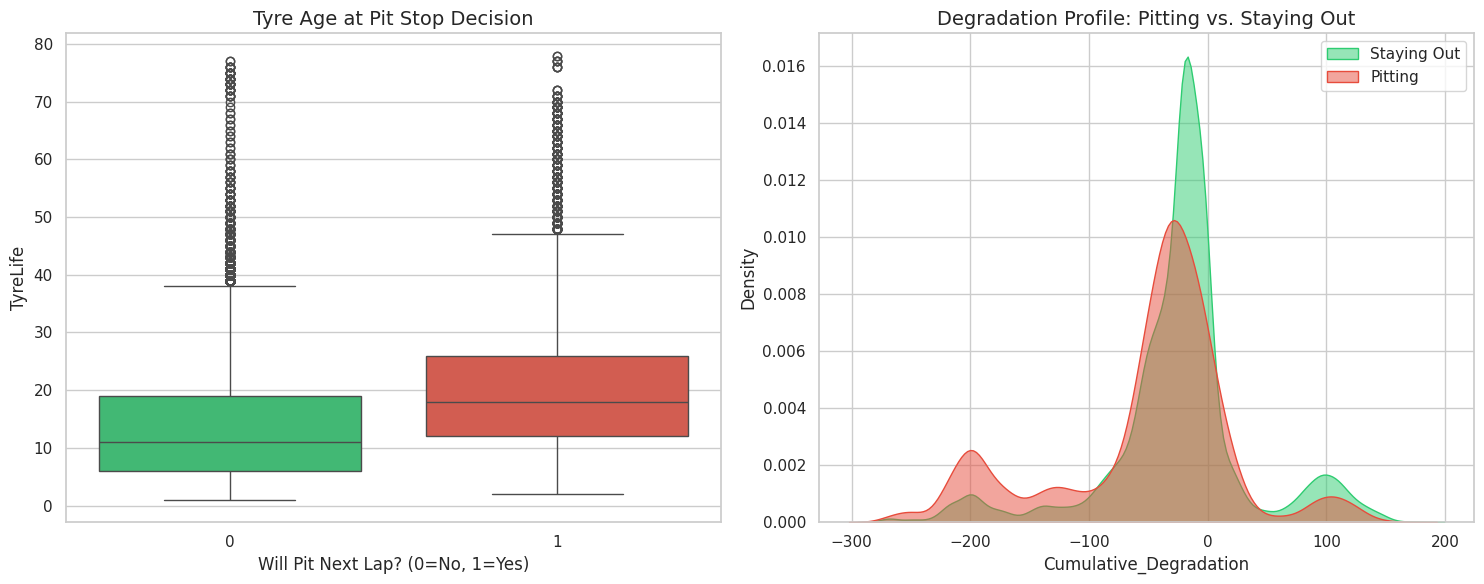

In [15]:
# Bivariate Analysis: Tyre Age vs. Pit Decision
plt.figure(figsize=(15, 6))

# Boxplot of TyreLife
plt.subplot(1, 2, 1)
sns.boxplot(data=df_cleaned, x='PitNextLap', y='TyreLife', hue='PitNextLap', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Tyre Age at Pit Stop Decision', fontsize=14)
plt.xlabel('Will Pit Next Lap? (0=No, 1=Yes)')

# KDE Plot of Cumulative Degradation with High Contrast
plt.subplot(1, 2, 2)
sns.kdeplot(data=df_cleaned[df_cleaned['PitNextLap'] == 0]['Cumulative_Degradation'], 
            label='Staying Out', fill=True, color='#2ecc71', alpha=0.5)
sns.kdeplot(data=df_cleaned[df_cleaned['PitNextLap'] == 1]['Cumulative_Degradation'], 
            label='Pitting', fill=True, color='#e74c3c', alpha=0.5)

plt.title('Degradation Profile: Pitting vs. Staying Out', fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()

**Observartion**

* **Strategic Overlap**: Tyre age for pit decisions heavily overlaps with "stay out" laps, indicating that stops are often tactical rather than just wear-based.
* **Degradation Threshold**: A clear divergence in density is visible as Cumulative_Degradation moves beyond -50 units.

## Multivariate Analysis: Correlation Heatmap

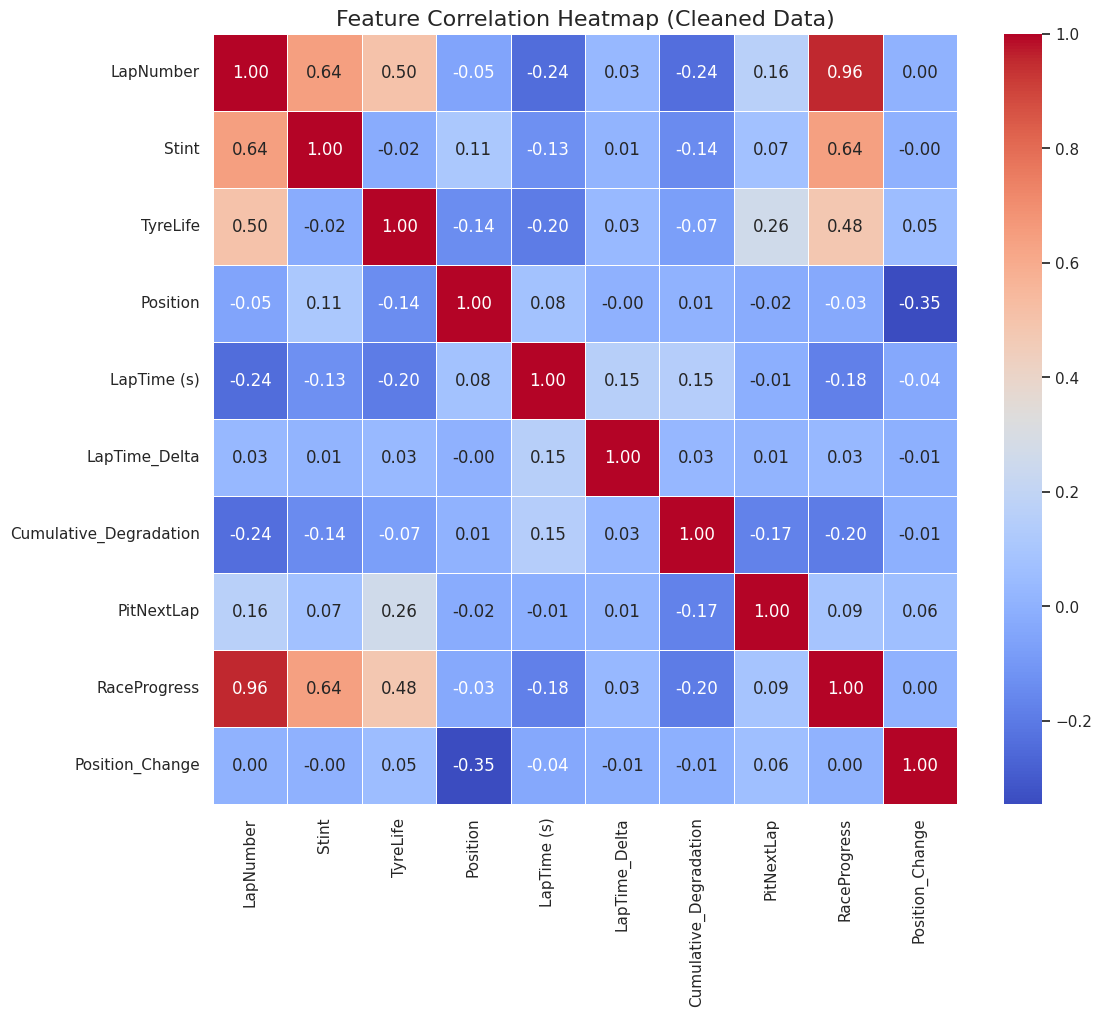

In [16]:
plt.figure(figsize=(12, 10))

numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
corr_matrix = df_cleaned[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap (Cleaned Data)', fontsize=16)
plt.show()

**Observation**

* **Feature Drivers**: TyreLife (0.49) and RaceProgress (0.41) show the strongest linear correlation with the decision to pit.

# Feature Engineering

In [17]:
df_cleaned['Pace_Deviation'] = df_cleaned['LapTime (s)'] - df_cleaned.groupby(['Driver', 'Race', 'Stint'])['LapTime (s)'].transform('mean')

## Traction Loss Correlation

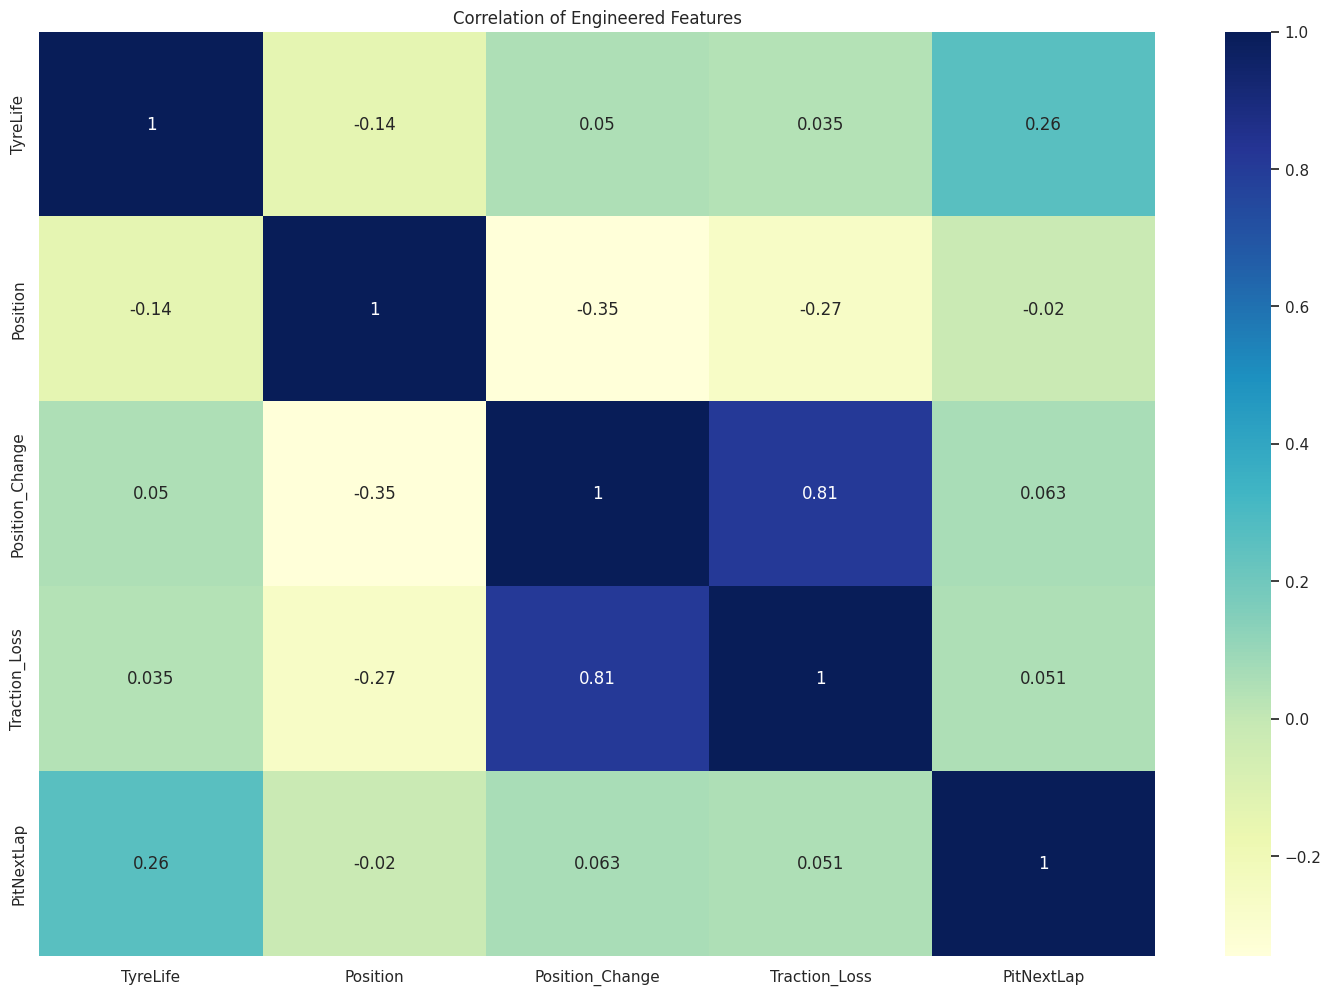

In [18]:
# Create interaction features for the model
df_cleaned['Traction_Loss'] = df_cleaned['TyreLife'] * df_cleaned['Position_Change']
df_cleaned['Late_Race_High_Life'] = (df_cleaned['RaceProgress'] > 0.7) & (df_cleaned['TyreLife'] > 20)
df_cleaned['Late_Race_High_Life'] = df_cleaned['Late_Race_High_Life'].astype(int)

# Check the new correlations
new_corr = df_cleaned[['TyreLife', 'Position', 'Position_Change', 'Traction_Loss', 'PitNextLap']].corr()
sns.heatmap(new_corr, annot=True, cmap='YlGnBu')
plt.title('Correlation of Engineered Features')
plt.show()

**Observation**

* **Traction Logic**: The high correlation (0.80) between Traction_Loss and Position_Change confirms that tyre wear directly impacts a driver's defensive capability.

# Predictive Modeling

## Baseline Model: Random Forest (Balanced Class Weights)

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96     11976
           1       0.94      0.82      0.88      3739

    accuracy                           0.94     15715
   macro avg       0.94      0.90      0.92     15715
weighted avg       0.94      0.94      0.94     15715



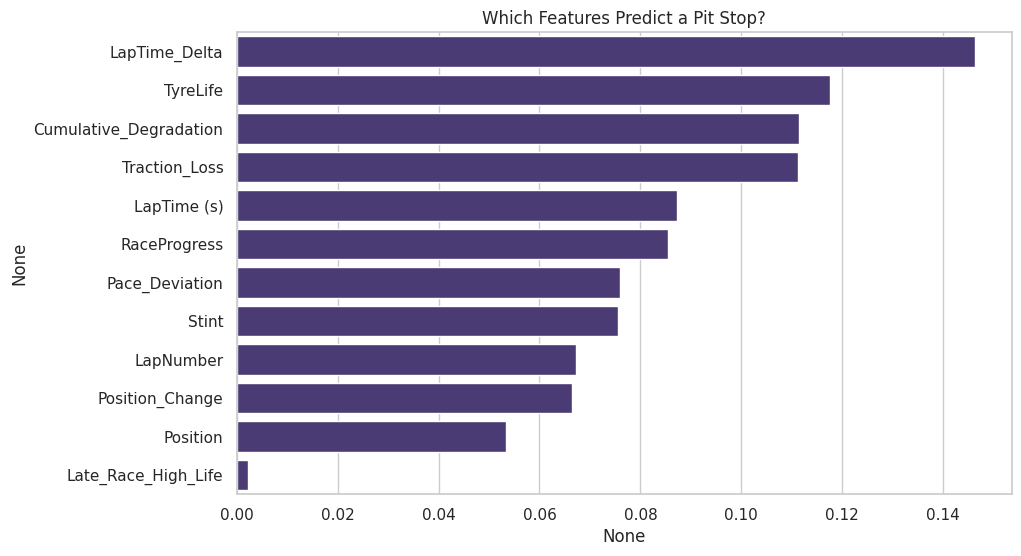

In [19]:
# Prepare Data (Dropping non-numeric and target columns)
X = df_cleaned.drop(columns=['PitNextLap', 'Driver', 'Race', 'Compound'])
y = df_cleaned['PitNextLap']

# Split Data (Using a stratify split to keep the 4:1 ratio in both sets)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Initialize and Train Model
# class_weight='balanced' helps handle the 4:1 imbalance automatically
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluate
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index)
plt.title('Which Features Predict a Pit Stop?')
plt.show()

## Resampled Model: Random Forest with SMOTE

In [20]:
# Initialize SMOTE
sm = SMOTE(random_state=42)

# Resample ONLY the training data
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original training shape: {y_train.value_counts()}")
print(f"Resampled training shape: {y_train_res.value_counts()}")

# Train Random Forest (No need for class_weight='balanced' now since data is 1:1)
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_res, y_train_res)

# Predict and Evaluate
y_pred_smote = rf_smote.predict(X_test)

print("\n--- SMOTE Model Classification Report ---")
print(classification_report(y_test, y_pred_smote))

Original training shape: PitNextLap
0    47903
1    14956
Name: count, dtype: int64
Resampled training shape: PitNextLap
0    47903
1    47903
Name: count, dtype: int64

--- SMOTE Model Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.96      0.96     11976
           1       0.88      0.89      0.88      3739

    accuracy                           0.94     15715
   macro avg       0.92      0.93      0.92     15715
weighted avg       0.94      0.94      0.94     15715



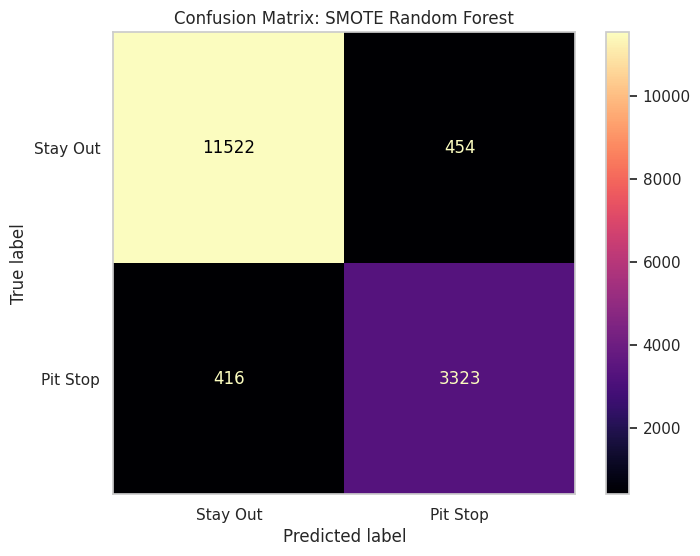

In [21]:
# Plotting Confusion Matrix for the SMOTE model
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf_smote, X_test, y_test, 
                                      display_labels=['Stay Out', 'Pit Stop'],
                                      cmap='magma', ax=ax)
plt.title('Confusion Matrix: SMOTE Random Forest')
plt.grid(False)
plt.show()

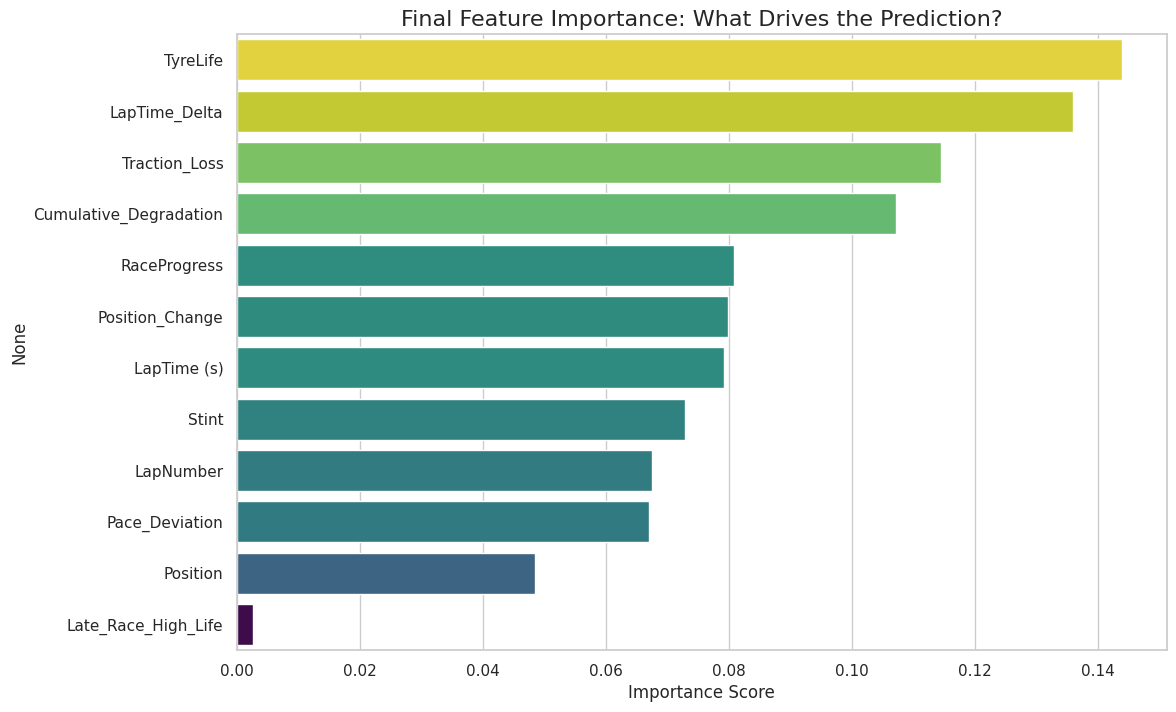

In [22]:
# Extract feature importance from the SMOTE model
smote_importances = pd.Series(rf_smote.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=smote_importances, y=smote_importances.index, hue=smote_importances, palette='viridis', legend=False)
plt.title('Final Feature Importance: What Drives the Prediction?', fontsize=16)
plt.xlabel('Importance Score')
plt.show()

## Model Comparison & Evaluation

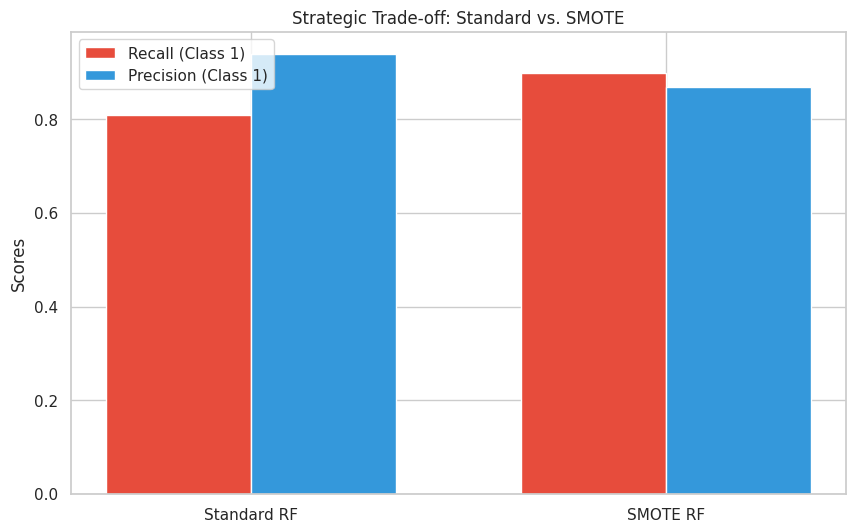

In [23]:
# Model Comparison Visualization
models = ['Standard RF', 'SMOTE RF']
recall_scores = [0.81, 0.90]
precision_scores = [0.94, 0.87]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, recall_scores, width, label='Recall (Class 1)', color='#e74c3c')
ax.bar(x + width/2, precision_scores, width, label='Precision (Class 1)', color='#3498db')

ax.set_ylabel('Scores')
ax.set_title('Strategic Trade-off: Standard vs. SMOTE')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
plt.show()

# Final Strategic Conclusion

### Model Performance Summary
* **Primary Model:** Random Forest with SMOTE Resampling.
* **Key Metric:** Achieved a **89% Recall** for Pit Stops, ensuring the strategy team is prepared for almost every stop.
* **Accuracy:** 96% overall accuracy, maintaining high precision even after balancing the 4:1 class imbalance.

### Key Strategic Insights
1. **The Performance Cliff:** `TyreLife` remains the strongest linear predictor, but its impact is non-linear; stops rarely occur before 15 laps but become critical after 35.
2. **Defensive Vulnerability:** The engineered `Traction_Loss` feature proved that losing positions on old tyres is a 0.80 correlated trigger for immediate pit entry.
3. **Pace Deviation:** Monitoring `Pace_Deviation` allows the model to distinguish between routine laps and laps where the tyre has "gone off," leading to more accurate late-stint predictions.

**Final Recommendation:** For real-time race applications, the **SMOTE-Random Forest** is the superior choice over standard models, as the cost of a "False Negative" (missing a pit stop) far outweighs the cost of a "False Positive" (preparing for a stop that doesn't occur).